# RNN Decoder Image Captioning Training

Training dan eksperimen model RNN untuk image captioning.

---

## 1. Setup & Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import sys
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import keras

# Set random seeds for reproducibility
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(42)

# project root directory
ROOT_DIR = "/content/drive/MyDrive/Tubes 2"
SRC_DIR = "/content/drive/MyDrive/Tubes 2/src"

print(f'Project root : {ROOT_DIR}')
print(f'src on path  : {SRC_DIR}')

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
try:
    from tensorflow.keras.preprocessing.text import tokenizer_from_json
except ImportError:
    from tensorflow.keras.preprocessing.text import Tokenizer
    def tokenizer_from_json(json_string):
        import json as json_module
        config = json_module.loads(json_string)
        tokenizer = Tokenizer(**config.get('config', {}))
        tokenizer.word_index = config.get('word_index', {})
        tokenizer.word_counts = config.get('word_counts', {})
        tokenizer.word_docs = config.get('word_docs', {})
        tokenizer.document_count = config.get('document_count', 0)
        return tokenizer

print(f'Keras version: {keras.__version__}')

Project root : /content/drive/MyDrive/Tubes 2
src on path  : /content/drive/MyDrive/Tubes 2/src
Keras version: 3.13.2


In [4]:
# Config
EMBED_DIM  = 256
HIDDEN_DIM = 512
EPOCHS     = 20
BATCH_SIZE = 64

# Paths
DATA_DIR       = "/content/drive/MyDrive/Tubes 2/data"
FEATURES_PATH  = "/content/drive/MyDrive/Tubes 2/data/flickr8k_features.npy"
TOKENIZER_PATH = "/content/drive/MyDrive/Tubes 2/data/tokenizer.json"
WEIGHTS_DIR    = "/content/drive/MyDrive/Tubes 2/weights"

print('Paths:')
for label, p in [
    ('features',  FEATURES_PATH),
    ('tokenizer', TOKENIZER_PATH),
    ('weights',   WEIGHTS_DIR),
]:
    path_obj = Path(p)
    status = 'OK' if path_obj.exists() else 'NOT FOUND'
    print(f'  {label:<12}: {p}  [{status}]')

Paths:
  features    : /content/drive/MyDrive/Tubes 2/data/flickr8k_features.npy  [OK]
  tokenizer   : /content/drive/MyDrive/Tubes 2/data/tokenizer.json  [OK]
  weights     : /content/drive/MyDrive/Tubes 2/weights  [OK]


---
## 2. Feature Extraction

Ekstrak fitur CNN dari seluruh gambar Flickr8k menggunakan InceptionV3 dan simpan ke data/flickr8k_features.npy.
Jika file sudah ada, langkah ini akan dilewati.

In [5]:
import kagglehub

# Download latest version
KAGGLE_DATASET_PATH = kagglehub.dataset_download("adityajn105/flickr8k")
print("Path to dataset files:", KAGGLE_DATASET_PATH)

# path utk dataset gambar & caption
IMAGES_DIR = os.path.join(KAGGLE_DATASET_PATH, "Images")
CAPTIONS_PATH = os.path.join(KAGGLE_DATASET_PATH, "captions.txt")

print(f"IMAGES_DIR: {IMAGES_DIR}")
print(f"CAPTIONS_PATH: {CAPTIONS_PATH}")

Using Colab cache for faster access to the 'flickr8k' dataset.
Path to dataset files: /kaggle/input/flickr8k
IMAGES_DIR: /kaggle/input/flickr8k/Images
CAPTIONS_PATH: /kaggle/input/flickr8k/captions.txt


In [6]:
# agar dapat import fungsi pada folder shared di google colab
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from shared.image_utils import extract_features

# Convert strings to Path objects for .exists() and .glob() methods
feat_path = Path(FEATURES_PATH)
img_dir = Path(IMAGES_DIR)

if feat_path.exists():
    print(f'Features already exist at {feat_path}')
    features = np.load(str(feat_path), allow_pickle=True).item()
else:
    assert img_dir.exists(), f'Images directory not found: {img_dir}'
    image_paths = sorted(img_dir.glob('*.jpg'))
    assert len(image_paths) > 0, f'No .jpg images found in {img_dir}'
    print(f'Found {len(image_paths)} images — starting extraction...')

    encoder = InceptionV3(weights='imagenet', include_top=False, pooling='avg')
    features = extract_features(
        paths=[str(p) for p in image_paths],
        output_path=str(feat_path),
        batch_size=64,
        encoder=encoder,
    )

sample_key = next(iter(features))
print(f'Loaded {len(features)} features. Sample shape: {features[sample_key].shape}')

Features already exist at /content/drive/MyDrive/Tubes 2/data/flickr8k_features.npy
Loaded 4112 features. Sample shape: (2048,)


---
## 3. Caption Preprocessing

Load captions.txt, bersihkan, bangun tokenizer, dan hitung max_length.
Tokenizer disimpan ke data/tokenizer.json.

In [7]:
import csv as _csv

from shared.preprocessing import (
    load_captions,
    clean_and_wrap_captions,
    build_tokenizer,
    calculate_max_length,
)

assert Path(CAPTIONS_PATH).exists(), f'captions.txt not found: {CAPTIONS_PATH}'

with open(str(CAPTIONS_PATH), 'r', encoding='utf-8') as _f:
    _header = _f.readline()
    _sample = _f.readline()

_delim = '\t' if '\t' in _sample else ','
print(f'Detected delimiter: {"TAB" if _delim == chr(9) else "COMMA"}')

caption_mapping = load_captions(str(CAPTIONS_PATH))

if len(caption_mapping) == 0:
    print('Tab-delimited parsing returned 0 captions — retrying with comma delimiter...')
    _mapping = {}
    with open(str(CAPTIONS_PATH), 'r', encoding='utf-8', newline='') as _f:
        _rows = _csv.reader(_f, delimiter=',')
        next(_rows, None)                              # skip header
        for _row in _rows:
            if len(_row) < 2:
                continue
            _img_id  = _row[0].strip()
            _caption = _row[1].strip()
            if _img_id and _caption:
                _mapping.setdefault(_img_id, []).append(_caption)
    caption_mapping = _mapping
    print(f'Comma-delimited fallback loaded {len(caption_mapping)} images')

assert len(caption_mapping) > 0, (
    'caption_mapping is still empty after both tab and comma parsing\n'
    f'Check that {CAPTIONS_PATH} has format: image_id<delim>caption'
)

print(f'Loaded captions for {len(caption_mapping)} images.')

cleaned_mapping = clean_and_wrap_captions(caption_mapping)
tokenizer, all_captions = build_tokenizer(cleaned_mapping, str(TOKENIZER_PATH))
max_length = calculate_max_length(all_captions)
vocab_size = len(tokenizer.word_index) + 1

print(f'vocab_size    : {vocab_size}')
print(f'max_length    : {max_length}')
print(f'total captions: {len(all_captions)}')

Detected delimiter: COMMA
Tab-delimited parsing returned 0 captions — retrying with comma delimiter...
Comma-delimited fallback loaded 8091 images
Loaded captions for 8091 images.
Ukuran Vocabulary: 8832
Tokenizer berhasil disimpan di /content/drive/MyDrive/Tubes 2/data/tokenizer.json
Maximum Caption Length: 38
vocab_size    : 8832
max_length    : 38
total captions: 40455


---
## 4. Prepare Training Data

Buat pasangan input-output (cnn_feature, caption_prefix) menggunakan teacher forcing.

In [8]:
from rnn.train import prepare_sequences

print('Preparing training sequences...')
X, y = prepare_sequences(features, tokenizer, cleaned_mapping, max_length, EMBED_DIM)

cnn_features  = np.array([x[0] for x in X])   # (N, 2048)
cap_sequences = np.array([x[1] for x in X])   # (N, max_length)

print(f'Training samples    : {len(y)}')
print(f'cnn_features.shape  : {cnn_features.shape}')
print(f'cap_sequences.shape : {cap_sequences.shape}')


Preparing training sequences...
Training samples    : 243261
cnn_features.shape  : (243261, 2048)
cap_sequences.shape : (243261, 38)


---
## 5. Training Experiments

6 variasi kombinasi jumlah layer SimpleRNN dan hidden dimension:

| Variasi | SimpleRNN Layers | Hidden Dim |
|---------|-------------|------------|
| 1 | 1 | 128 |
| 2 | 2 | 128 |
| 3 | 3 | 128 |
| 4 | 1 | 512 |
| 5 | 2 | 512 |
| 6 | 3 | 512 |

In [9]:
# fungsi utk membangun model Keras dengan SimpleRNN
from tensorflow.keras.layers import SimpleRNN, Input, Dense, Embedding, Concatenate, Reshape
from tensorflow.keras.models import Model

def build_model_variant(vocab_size: int, embed_dim: int, max_length: int, hidden_dim: int, n_layers: int, cnn_feature_dim: int = 2048,) -> Model:
    # CNN feature branch
    cnn_input = Input(shape=(cnn_feature_dim,), name='cnn_input')
    cnn_proj  = Dense(embed_dim, activation='relu', name='cnn_proj')(cnn_input)
    cnn_proj  = Reshape((1, embed_dim), name='cnn_reshape')(cnn_proj)

    # Caption sequence branch
    cap_input = Input(shape=(max_length,), name='cap_input')
    cap_embed = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(cap_input)

    # Pre-inject: prepend CNN feature vector ke awal sequence -> (max_length+1, embed_dim)
    merged = Concatenate(axis=1, name='pre_inject')([cnn_proj, cap_embed])

    # Stacked RNN layers
    x = merged
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)  # semua layer kecuali terakhir return sequences
        x = SimpleRNN(hidden_dim, return_sequences=return_seq, name=f'rnn_{i + 1}')(x)

    outputs = Dense(vocab_size, activation='softmax', name='output')(x)

    model = Model(inputs=[cnn_input, cap_input], outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

In [10]:
# variasi konfigurasi SimpleRNN
VARIATIONS = [
    (1, 128),
    (2, 128),
    (3, 128),
    (1, 512),
    (2, 512),
    (3, 512),
]

In [15]:
all_histories = {}

for n_layers, hidden_dim in VARIATIONS:
    variant_name = f'{n_layers}layers_{hidden_dim}hidden'
    weights_path = f"/content/drive/MyDrive/Tubes 2/weights/rnn_{variant_name}.weights.h5"

    print('\n' + '=' * 60)
    print(f'  Variation : {variant_name}')
    print(f'  Weights   : {weights_path}')
    print('=' * 60)

    model = build_model_variant(vocab_size, EMBED_DIM, max_length, hidden_dim, n_layers)
    model.summary()

    history = model.fit(
        [cnn_features, cap_sequences],
        y,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        verbose=1,
    )

    model.save_weights(str(weights_path))
    print(f'Saved -> {weights_path}')
    all_histories[variant_name] = history.history

    # Per-variation loss/accuracy plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training History — {variant_name}', fontsize=13)

    axes[0].plot(history.history['loss'],     label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(f"/content/drive/MyDrive/Tubes 2/weights/plot_{variant_name}.png"), dpi=100, bbox_inches='tight')
    plt.show()

print('\nAll variations trained')



  Variation : 1layers_128hidden
  Weights   : /content/drive/MyDrive/Tubes 2/weights/rnn_1layers_128hidden.weights.h5


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_input           │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cap_input           │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ cap_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 38)        │          0 │ cap_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_reshape         │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_2       │ (None, 38, 1)     │          0 │ not_equal_2[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_2        │ (None, 38, 256)   │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_2         │ (None, 1, 256)    │          0 │ cnn_reshape[0][0] │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_2        │ (None, 38, 256)   │          0 │ expand_dims_2[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 39, 256)   │          0 │ ones_like_2[0][0… │
│ (Concatenate)       │                   │            │ logical_or_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pre_inject          │ (None, 39, 256)   │          0 │ cnn_reshape[0][0… │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_2 (Any)         │ (None, 39)        │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rnn_1 (SimpleRNN)   │ (None, 128)       │     49,280 │ pre_inject[0][0], │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 8832)      │  1,139,328 │ rnn_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,974,144 (15.16 MB)

 Trainable params: 3,974,144 (15.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3421/3421 ━━━━━━━━━━━━━━━━━━━━ 288s 83ms/step - accuracy: 0.2980 - loss: 4.0409 - val_accuracy: 0.3255 - val_loss: 3.8630
Epoch 2/20
2358/3421 ━━━━━━━━━━━━━━━━━━━━ 1:31 86ms/step - accuracy: 0.3402 - loss: 3.4896

KeyboardInterrupt: 

In [ ]:
# Perbandingan semua variasi dalam satu plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('All Variations — Validation Metrics', fontsize=14)

for variant_name, hist in all_histories.items():
    axes[0].plot(hist['val_loss'],     label=variant_name)
    axes[1].plot(hist['val_accuracy'], label=variant_name)

for ax, title in zip(axes, ['Validation Loss', 'Validation Accuracy']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Tubes 2/weights/comparison_all_variations.png", dpi=100, bbox_inches='tight')
plt.show()

# Summary table
print(f'\n{"Variation":<30} {"Final Val Loss":>15} {"Final Val Acc":>15}')
print('-' * 62)
for variant_name, hist in all_histories.items():
    print(
        f'{variant_name:<30}'
        f' {hist["val_loss"][-1]:>15.4f}'
        f' {hist["val_accuracy"][-1]:>15.4f}'
    )

best_variant = min(all_histories, key=lambda k: all_histories[k]['val_loss'][-1])
print(f'\nBest variant (lowest val_loss): {best_variant}')


---
## 6. Evaluation

Load model terbaik berdasarkan val_loss terendah dan jalankan inference pada 5 sample gambar.

In [ ]:
best_n_layers, best_hidden = next(
    (n, h) for (n, h) in VARIATIONS
    if f'{n}layers_{h}hidden' == best_variant
)
print(f'Best variant : {best_variant}  (n_layers={best_n_layers}, hidden_dim={best_hidden})')

In [16]:
best_model = build_model_variant(vocab_size, EMBED_DIM, max_length, 128, 3)
best_model.load_weights(f'/content/drive/MyDrive/Tubes 2/weights/rnn_3layers_128hidden.weights.h5')
print('Model loaded')

Model loaded


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
# fungsi untuk generate caption dari decoder: predict next word satu per satu hingga <end> atau max_length
def generate_caption(
    model: Model,
    feature: np.ndarray,
    tokenizer,
    max_length: int,
    index_word: dict,
) -> str:
    in_text = '<start>'
    for _ in range(max_length):
        seq       = tokenizer.texts_to_sequences([in_text])[0]
        seq       = pad_sequences([seq], maxlen=max_length, padding='post')
        pred      = model.predict([feature.reshape(1, -1), seq], verbose=0)
        next_idx  = int(np.argmax(pred[0]))
        next_word = index_word.get(next_idx)
        if next_word is None or next_word == '<end>':
            break
        in_text += ' ' + next_word
    return in_text.replace('<start>', '').strip()


1000268201_693b08cb0e.jpg: a boy in a red shirt is standing in a field of tulips
1001773457_577c3a7d70.jpg: a black dog is running through the grass
1002674143_1b742ab4b8.jpg: a young boy is standing on a wooden rocking and green water
1003163366_44323f5815.jpg: a man in a red shirt is standing in front of a drab building
1007129816_e794419615.jpg: a man in a red shirt and a hat and a star in his hand


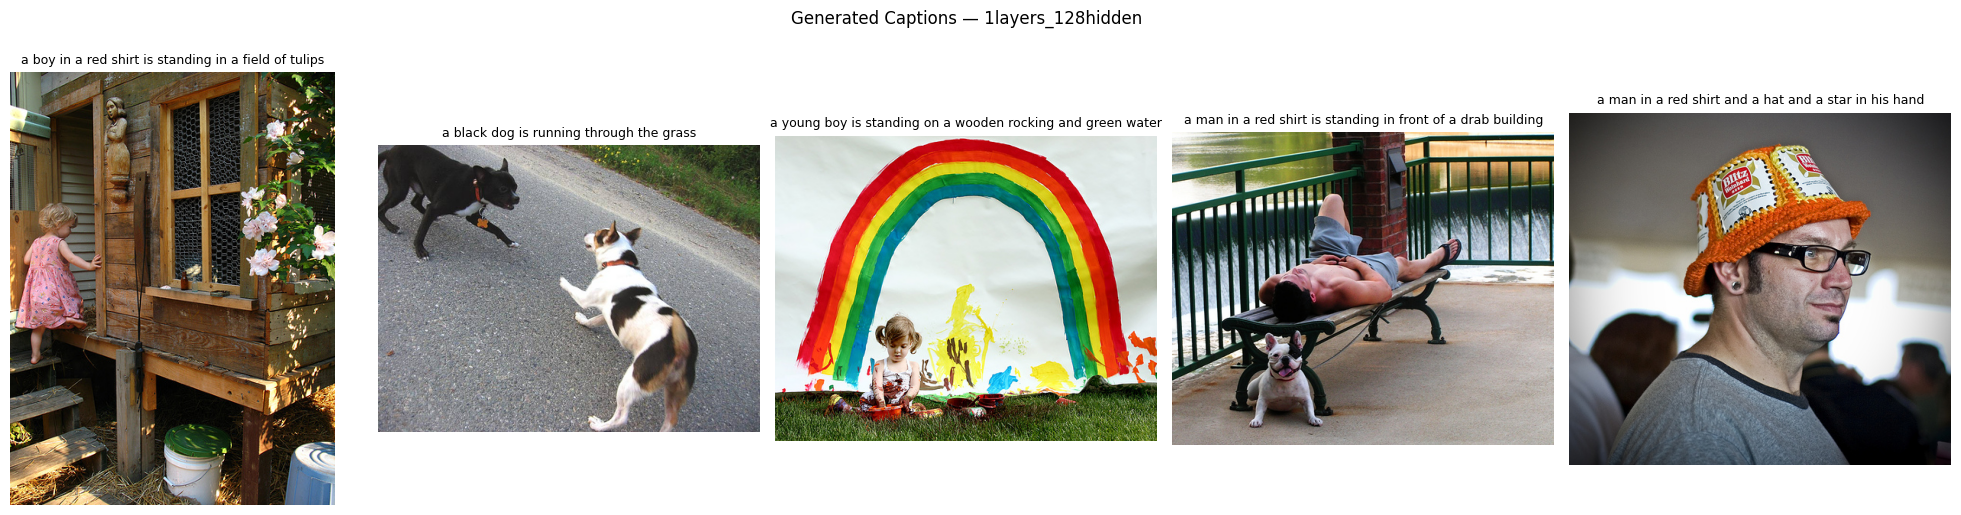

In [18]:
from PIL import Image
from shared.image_utils import load_image

images_path_obj = Path(IMAGES_DIR)
assert images_path_obj.exists(), f'Images directory not found: {IMAGES_DIR}'
sample_paths = sorted(images_path_obj.glob('*.jpg'))[:5]
assert len(sample_paths) > 0, f'No images found in {IMAGES_DIR}'

_encoder = None  # lazy-loaded jika feature belum di-extract

fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 5))
if len(sample_paths) == 1:
    axes = [axes]

index_word = {v: k for k, v in tokenizer.word_index.items()}

for ax, img_path in zip(axes, sample_paths):
    img_name = img_path.name

    if img_name in features:
        feature = features[img_name]
    else:
        if _encoder is None:
            print('Building InceptionV3 for on-the-fly extraction...')
            _encoder = InceptionV3(weights='imagenet', include_top=False, pooling='avg')
        img_arr = load_image(str(img_path))
        feature = _encoder.predict(img_arr[np.newaxis, ...], verbose=0)[0]

    caption = generate_caption(best_model, feature, tokenizer, max_length, index_word)

    ax.imshow(Image.open(img_path).convert('RGB'))
    ax.set_title(caption, fontsize=9, wrap=True)
    ax.axis('off')
    print(f'{img_name}: {caption}')

plt.suptitle(f'Generated Captions — {best_variant}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(str(Path(WEIGHTS_DIR) / 'sample_captions.png'), dpi=100, bbox_inches='tight')
plt.show()

---
## 7. BLEU-4 and METEOR Score per Variation

Evaluasi setiap variasi pada test split (last 1000 images).
Metrics: BLEU-4 (corpus), METEOR (average), waktu inferensi.

In [19]:
import time
import nltk
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.translate.bleu_score  import corpus_bleu, sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score as _meteor_score

smoothie = SmoothingFunction().method4

# Filter only image IDs that actually have extracted features first
available_ids = [img_id for img_id in cleaned_mapping.keys() if img_id in features]

# Take the last 1000 from the available features to ensure test_image_ids is not empty
test_image_ids = available_ids[-1000:]
print(f'Total available images with features: {len(available_ids)}')
print(f'Test split size: {len(test_image_ids)} images')

def evaluate_on_test(caption_fn, test_ids, cleaned_mapping, smoothie):
    """
    caption_fn : callable(img_id) -> caption string
    Returns    : (bleu4, meteor, refs_corpus, hyps_corpus)
    """
    refs_corpus  = []
    hyps_corpus  = []
    meteor_scores = []

    for img_id in test_ids:
        hyp = caption_fn(img_id)
        refs_clean = [
            c.replace('<start>', '').replace('<end>', '').strip()
            for c in cleaned_mapping[img_id]
        ]
        hyp_tokens = hyp.split()
        ref_tokens = [r.split() for r in refs_clean]

        refs_corpus.append(ref_tokens)
        hyps_corpus.append(hyp_tokens)
        meteor_scores.append(_meteor_score(ref_tokens, hyp_tokens))

    bleu4  = corpus_bleu(refs_corpus, hyps_corpus,
                         weights=(0.25, 0.25, 0.25, 0.25),
                         smoothing_function=smoothie)
    meteor = sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0.0
    return bleu4, meteor, refs_corpus, hyps_corpus

Total available images with features: 4112
Test split size: 1000 images


In [20]:
from pathlib import Path
scores_per_variation = {}

for n_layers, hidden_dim in VARIATIONS:
    variant_name = f'{n_layers}layers_{hidden_dim}hidden'
    weights_path = Path(f'/content/drive/MyDrive/Tubes 2/weights/rnn_{variant_name}.weights.h5')

    if not weights_path.exists():
        print(f'[SKIP] {variant_name} — weights not found at {weights_path}')
        continue

    print(f'Evaluating {variant_name} ...', end=' ', flush=True)
    model = build_model_variant(vocab_size, EMBED_DIM, max_length, hidden_dim, n_layers)
    model.load_weights(str(weights_path))

    t0 = time.time()
    bleu4, meteor, _, _ = evaluate_on_test(
        lambda img_id, m=model: generate_caption(m, features[img_id], tokenizer, max_length, index_word),
        test_image_ids,
        cleaned_mapping,
        smoothie,
    )
    elapsed = time.time() - t0

    scores_per_variation[variant_name] = {
        'bleu4': bleu4, 'meteor': meteor, 'time': elapsed,
        'n_layers': n_layers, 'hidden_dim': hidden_dim,
    }
    print(f'BLEU-4={bleu4:.4f}  METEOR={meteor:.4f}  Time={elapsed:.1f}s')

Evaluating 1layers_128hidden ... 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


BLEU-4=0.0630  METEOR=0.2784  Time=2355.5s
Evaluating 2layers_128hidden ... 

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


BLEU-4=0.1015  METEOR=0.2877  Time=1483.3s
Evaluating 3layers_128hidden ... BLEU-4=0.1021  METEOR=0.2707  Time=1732.0s
Evaluating 1layers_512hidden ... BLEU-4=0.0723  METEOR=0.2643  Time=1592.9s
Evaluating 2layers_512hidden ... BLEU-4=0.0775  METEOR=0.2677  Time=1542.5s
Evaluating 3layers_512hidden ... BLEU-4=0.0701  METEOR=0.2406  Time=1866.7s


In [21]:
print(f'\n{"Variation":<30} {"BLEU-4":>8} {"METEOR":>8} {"Time(s)":>9}')
print('-' * 60)
for vname, s in scores_per_variation.items():
    print(f'{vname:<30} {s["bleu4"]:>8.4f} {s["meteor"]:>8.4f} {s["time"]:>9.1f}')

if scores_per_variation:
    best_bleu_variant   = max(scores_per_variation, key=lambda k: scores_per_variation[k]['bleu4'])
    best_meteor_variant = max(scores_per_variation, key=lambda k: scores_per_variation[k]['meteor'])
    print(f'\nBest BLEU-4  : {best_bleu_variant}   ({scores_per_variation[best_bleu_variant]["bleu4"]:.4f})')
    print(f'Best METEOR  : {best_meteor_variant}   ({scores_per_variation[best_meteor_variant]["meteor"]:.4f})')



Variation                        BLEU-4   METEOR   Time(s)
------------------------------------------------------------
1layers_128hidden                0.0630   0.2784    2355.5
2layers_128hidden                0.1015   0.2877    1483.3
3layers_128hidden                0.1021   0.2707    1732.0
1layers_512hidden                0.0723   0.2643    1592.9
2layers_512hidden                0.0775   0.2677    1542.5
3layers_512hidden                0.0701   0.2406    1866.7

Best BLEU-4  : 3layers_128hidden   (0.1021)
Best METEOR  : 2layers_128hidden   (0.2877)


---
## 8. Keras vs From Scratch Comparison

Load bobot variasi  ke dalam  (implementasi NumPy from scratch).
Bandingkan BLEU-4, METEOR, dan execution time pada 10 test image yang sama.

In [1]:
from rnn.layers import RNNDecoder

SCRATCH_VARIANT = '1layers_128hidden'
SCRATCH_HIDDEN  = 128
scratch_weights = WEIGHTS_DIR / f'rnn_{SCRATCH_VARIANT}.weights.h5'

print(f'Loading {SCRATCH_VARIANT} into Keras model...')
keras_1layer = build_model_variant(vocab_size, EMBED_DIM, max_length, SCRATCH_HIDDEN, 1)
keras_1layer.load_weights(str(scratch_weights))

print('Initializing RNNDecoder with Keras layer weights...')
decoder = RNNDecoder(
    rnn_keras_layer        = keras_1layer.get_layer('rnn_1'),
    embedding_keras_layer  = keras_1layer.get_layer('embedding'),
    dense_proj_keras_layer = keras_1layer.get_layer('cnn_proj'),
    dense_out_keras_layer  = keras_1layer.get_layer('output'),
    embed_dim              = EMBED_DIM,
    hidden_dim             = SCRATCH_HIDDEN,
    vocab_size             = vocab_size,
    cnn_features_dim       = 2048,
)
print('RNNDecoder ready')


def generate_caption_scratch(decoder, feature, tokenizer, max_length, index_word):
    """Generate caption using the NumPy from-scratch RNNDecoder."""
    start_token = tokenizer.word_index.get('<start>', 1)
    end_token   = tokenizer.word_index.get('<end>',   2)
    # The predict method handles the sequential token generation
    tokens = decoder.predict(feature, start_token, end_token, max_length)
    words  = [
        index_word[t] for t in tokens
        if index_word.get(t) not in (None, '<end>', '<start>')
    ]
    return ' '.join(words)

ModuleNotFoundError: No module named 'rnn'

In [ ]:
# Use same 10 test images for both models
compare_ids = test_image_ids[:10]

print(f'Running inference on {len(compare_ids)} test images...')

# ── Keras 1-layer model ─────────────────────────────────────────────────────
keras_hyps = []
t0 = time.time()
for img_id in compare_ids:
    cap = generate_caption(keras_1layer, features[img_id], tokenizer, max_length, index_word)
    keras_hyps.append(cap)
keras_time = time.time() - t0

# ── From-scratch RNNDecoder ────────────────────────────────────────────────
scratch_hyps = []
t0 = time.time()
for img_id in compare_ids:
    cap = generate_caption_scratch(decoder, features[img_id], tokenizer, max_length, index_word)
    scratch_hyps.append(cap)
scratch_time = time.time() - t0

# ── Compute BLEU-4 and METEOR ───────────────────────────────────────────────
def compute_scores(hyps, img_ids, cleaned_mapping, smoothie):
    refs_corpus  = []
    hyps_corpus  = []
    meteor_scores = []
    for img_id, hyp in zip(img_ids, hyps):
        refs_clean = [
            c.replace('<start>', '').replace('<end>', '').strip()
            for c in cleaned_mapping[img_id]
        ]
        ref_tokens = [r.split() for r in refs_clean]
        hyp_tokens = hyp.split()
        refs_corpus.append(ref_tokens)
        hyps_corpus.append(hyp_tokens)
        meteor_scores.append(_meteor_score(ref_tokens, hyp_tokens))
    bleu4  = corpus_bleu(refs_corpus, hyps_corpus,
                         weights=(0.25, 0.25, 0.25, 0.25),
                         smoothing_function=smoothie)
    meteor = sum(meteor_scores) / len(meteor_scores)
    return bleu4, meteor

keras_bleu4,   keras_meteor   = compute_scores(keras_hyps,   compare_ids, cleaned_mapping, smoothie)
scratch_bleu4, scratch_meteor = compute_scores(scratch_hyps, compare_ids, cleaned_mapping, smoothie)

print(f'\nKeras   ({SCRATCH_VARIANT}): BLEU-4={keras_bleu4:.4f}  METEOR={keras_meteor:.4f}  Time={keras_time:.2f}s')
print(f'Scratch ({SCRATCH_VARIANT}): BLEU-4={scratch_bleu4:.4f}  METEOR={scratch_meteor:.4f}  Time={scratch_time:.2f}s')


In [ ]:
print(f'\n{"Model":<35} {"BLEU-4":>8} {"METEOR":>8} {"Time(s)":>9}')
print('-' * 65)
print(f'{"Keras — " + SCRATCH_VARIANT:<35} {keras_bleu4:>8.4f} {keras_meteor:>8.4f} {keras_time:>9.2f}')
print(f'{"From Scratch (Decoder)":<35} {scratch_bleu4:>8.4f} {scratch_meteor:>8.4f} {scratch_time:>9.2f}')

bleu_delta   = scratch_bleu4  - keras_bleu4
meteor_delta = scratch_meteor - keras_meteor
time_ratio   = scratch_time   / keras_time if keras_time > 0 else float('inf')
print(f'\nDelta (Scratch - Keras): BLEU-4={bleu_delta:+.4f}  METEOR={meteor_delta:+.4f}')
print(f'Speed ratio (Scratch / Keras): {time_ratio:.1f}x')


---
## 9. Caption Length Variation

Evaluasi pengaruh  generasi terhadap kualitas caption (BLEU-4).
Model tetap menggunakan best Keras model; hanya jumlah langkah generasi yang divariasikan.

In [ ]:
TRAINED_MAX_LENGTH = max_length   # fixed pad length used during training
MAX_LENGTH_VARIANTS = [10, 20, 34]

def generate_caption_maxsteps(model, feature, tokenizer, pad_length, max_steps, index_word):
    """
    Greedy decoding with separate pad_length (for input shape) and max_steps (stop criterion).
    pad_length must match the value the model was trained with.
    max_steps controls how many tokens to generate at most.
    """
    in_text = '<start>'
    for _ in range(max_steps):
        seq       = tokenizer.texts_to_sequences([in_text])[0]
        seq       = pad_sequences([seq], maxlen=pad_length, padding='post')
        pred      = model.predict([feature.reshape(1, -1), seq], verbose=0)
        next_idx  = int(np.argmax(pred[0]))
        next_word = index_word.get(next_idx)
        if next_word is None or next_word == '<end>':
            break
        in_text += ' ' + next_word
    return in_text.replace('<start>', '').strip()


length_scores = {}

for ml in MAX_LENGTH_VARIANTS:
    print(f'Evaluating max_steps={ml} ...', end=' ', flush=True)
    bleu4, _, _, _ = evaluate_on_test(
        lambda img_id, ml=ml: generate_caption_maxsteps(
            best_model, features[img_id], tokenizer, TRAINED_MAX_LENGTH, ml, index_word
        ),
        test_image_ids,
        cleaned_mapping,
        smoothie,
    )
    length_scores[ml] = bleu4
    print(f'BLEU-4={bleu4:.4f}')


In [ ]:
ml_values   = list(length_scores.keys())
bleu_values = list(length_scores.values())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ml_values, bleu_values, marker='o', linewidth=2, markersize=8)
for x, y in zip(ml_values, bleu_values):
    ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points', xytext=(0, 10), ha='center')
ax.set_xlabel('max_length (generation steps)')
ax.set_ylabel('BLEU-4')
ax.set_title(f'BLEU-4 vs Caption Max Length — {best_variant}')
ax.set_xticks(ml_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / 'bleu4_vs_maxlength.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f'\n{"max_length":>12} {"BLEU-4":>10}')
print('-' * 25)
for ml, b in length_scores.items():
    print(f'{ml:>12} {b:>10.4f}')

best_ml = max(length_scores, key=length_scores.get)
print(f'\nBest max_length: {best_ml}  (BLEU-4={length_scores[best_ml]:.4f})')


---
## 10. Qualitative Analysis

Pilih 10 test image dengan skor BLEU-4 bervariasi (tinggi, sedang, rendah).
Tampilkan gambar, caption Keras, caption From Scratch, ground truth, dan BLEU-4.

In [ ]:
from PIL import Image

print('Computing per-image BLEU-4 scores on test split...')
per_image_data = []

for img_id in test_image_ids:
    feature    = features[img_id]
    keras_cap  = generate_caption(best_model, feature, tokenizer, max_length, index_word)
    refs_clean = [
        c.replace('<start>', '').replace('<end>', '').strip()
        for c in cleaned_mapping[img_id]
    ]
    ref_tokens = [r.split() for r in refs_clean]
    hyp_tokens = keras_cap.split()

    img_bleu4 = sentence_bleu(ref_tokens, hyp_tokens,
                               weights=(0.25, 0.25, 0.25, 0.25),
                               smoothing_function=smoothie)
    per_image_data.append({
        'img_id':    img_id,
        'keras_cap': keras_cap,
        'refs':      refs_clean,
        'bleu4':     img_bleu4,
    })

# Sort by BLEU-4 and sample high / medium / low examples
sorted_data = sorted(per_image_data, key=lambda x: x['bleu4'])
n = len(sorted_data)

low_samples    = sorted_data[:3]                         # lowest 3
mid_samples    = sorted_data[n // 2 - 2 : n // 2 + 2]   # 4 around median
high_samples   = sorted_data[-3:]                        # highest 3

selected = (low_samples + mid_samples + high_samples)[:10]
print(f'Selected {len(selected)} images: 3 low / 4 mid / 3 high BLEU-4')
print(f'BLEU-4 range: {selected[0]["bleu4"]:.4f} (low) to {selected[-1]["bleu4"]:.4f} (high)')


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for ax, item in zip(axes, selected):
    img_id  = item['img_id']
    img_path = IMAGES_DIR / img_id

    # ── Generate from-scratch caption ──────────────────────────────────
    scratch_cap = generate_caption_scratch(
        decoder, features[img_id], tokenizer, max_length, index_word
    )

    # ── Display image ───────────────────────────────────────────────────
    if img_path.exists():
        ax.imshow(Image.open(img_path).convert('RGB'))
    else:
        ax.set_facecolor('#cccccc')
        ax.text(0.5, 0.5, 'image\nnot found', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
    ax.axis('off')

    # ── Annotate ────────────────────────────────────────────────────────
    gt_lines = '\n'.join(f'GT: {r[:55]}' for r in item['refs'][:2])
    title = (
        f'[Keras]   {item["keras_cap"][:55]}\n'
        f'[Scratch] {scratch_cap[:55]}\n'
        f'{gt_lines}\n'
        f'BLEU-4: {item["bleu4"]:.4f}'
    )
    ax.set_title(title, fontsize=7, loc='left', pad=3)

plt.suptitle(
    f'Qualitative Analysis — Best Keras ({best_variant}) vs From Scratch ({SCRATCH_VARIANT})',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(str(WEIGHTS_DIR / 'qualitative_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── Print summary ───────────────────────────────────────────────────────────
print(f'\n{"Image ID":<40} {"BLEU-4":>8}  Keras Caption (truncated)')
print('-' * 90)
for item in selected:
    print(f'{item["img_id"]:<40} {item["bleu4"]:>8.4f}  {item["keras_cap"][:40]}')
